In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hrish4/taxi-trip-fare-data-2023/Taxi_Trip_Data_preprocessed.csv


In [2]:
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
import warnings
warnings.filterwarnings(action='ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import Dataset,DataLoader

In [3]:
torch.manual_seed(42)

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
df = pd.read_csv('/kaggle/input/datasets/hrish4/taxi-trip-fare-data-2023/Taxi_Trip_Data_preprocessed.csv')

In [6]:
df.shape

(8451090, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8451090 entries, 0 to 8451089
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   passenger_count  int64  
 1   trip_distance    float64
 2   payment_type     object 
 3   fare_amount      float64
 4   duration         float64
dtypes: float64(3), int64(1), object(1)
memory usage: 322.4+ MB


In [8]:
df.isna().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
duration           0
dtype: int64

In [9]:
df['fare_per_km'] = df['fare_amount'] / (df['trip_distance'] + 1e-5)

In [10]:
df['speed'] = df['trip_distance'] / (df['duration'] + 1e-5)

In [11]:
df["log_distance"] = np.log1p(df["trip_distance"])
df["log_duration"] = np.log1p(df["duration"])

In [12]:
df = df[df["fare_amount"] < df["fare_amount"].quantile(0.99)]

In [13]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
encoder = LabelEncoder()

In [16]:
X_train['payment_type'] = encoder.fit_transform(X_train['payment_type'])
X_test['payment_type'] = encoder.transform(X_test['payment_type'])

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train.shape

(6688537, 8)

In [19]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train.values).float().view(-1, 1)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1, 1)

In [43]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [44]:
train_dataset = CustomDataset(X_train_tensor,y_train_tensor)
test_dataset = CustomDataset(X_test_tensor,y_test_tensor)

In [45]:
train_loader = DataLoader(train_dataset,batch_size=8192,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=8192,shuffle=False,pin_memory=True)

In [46]:
len(train_loader)

817

In [47]:
class NeuralNetwork(nn.Module):

    def __init__(self,n_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(n_dim,128),
            nn.SELU(),
            
            nn.Linear(128,64),
            nn.SELU(),

            nn.Linear(64,32),
            nn.SELU(),
            
            nn.Linear(32,16),
            nn.SELU(),
            nn.Dropout(0.2),

            nn.Linear(16,1)
            
        )

    def forward(self,x):
        return self.model(x)


In [48]:
model = NeuralNetwork(X_train_tensor.shape[1])

In [49]:
model = model.to(device)

In [50]:
summary(model)

Layer (type:depth-idx)                   Param #
NeuralNetwork                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       1,152
│    └─SELU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─SELU: 2-4                         --
│    └─Linear: 2-5                       2,080
│    └─SELU: 2-6                         --
│    └─Linear: 2-7                       528
│    └─SELU: 2-8                         --
│    └─Dropout: 2-9                      --
│    └─Linear: 2-10                      17
Total params: 12,033
Trainable params: 12,033
Non-trainable params: 0

In [51]:
learning_rate = 0.001
epochs = 50

In [52]:
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss,self).__init__()

    def forward(self,x,y):
        criterion = nn.MSELoss()
        loss = torch.sqrt(criterion(x, y))
        return loss

In [53]:
optimizer = optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-3)

criterion = RMSELoss()

In [54]:
### training loop
for epoch in range(epochs):

    model.train()
    
    total_epoch_loss = 0
    
    for batch_features,batch_labels in train_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        ### forward pass
        outputs = model(batch_features)

        ### loss calculations
        loss = criterion(outputs,batch_labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step() ### weight updation

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} ==> Loss {avg_loss:.4f}")

Epoch 1/50 ==> Loss 2.4167
Epoch 2/50 ==> Loss 1.6902
Epoch 3/50 ==> Loss 1.5794
Epoch 4/50 ==> Loss 1.4929
Epoch 5/50 ==> Loss 1.4095
Epoch 6/50 ==> Loss 1.3316
Epoch 7/50 ==> Loss 1.2531
Epoch 8/50 ==> Loss 1.1788
Epoch 9/50 ==> Loss 1.1078
Epoch 10/50 ==> Loss 1.0389
Epoch 11/50 ==> Loss 0.9746
Epoch 12/50 ==> Loss 0.9152
Epoch 13/50 ==> Loss 0.8627
Epoch 14/50 ==> Loss 0.8159
Epoch 15/50 ==> Loss 0.7789
Epoch 16/50 ==> Loss 0.7493
Epoch 17/50 ==> Loss 0.7251
Epoch 18/50 ==> Loss 0.7055
Epoch 19/50 ==> Loss 0.6917
Epoch 20/50 ==> Loss 0.6812
Epoch 21/50 ==> Loss 0.6740
Epoch 22/50 ==> Loss 0.6698
Epoch 23/50 ==> Loss 0.6653
Epoch 24/50 ==> Loss 0.6625
Epoch 25/50 ==> Loss 0.6618
Epoch 26/50 ==> Loss 0.6599
Epoch 27/50 ==> Loss 0.6590
Epoch 28/50 ==> Loss 0.6564
Epoch 29/50 ==> Loss 0.6562
Epoch 30/50 ==> Loss 0.6569
Epoch 31/50 ==> Loss 0.6560
Epoch 32/50 ==> Loss 0.6554
Epoch 33/50 ==> Loss 0.6549
Epoch 34/50 ==> Loss 0.6543
Epoch 35/50 ==> Loss 0.6548
Epoch 36/50 ==> Loss 0.6542
E

In [55]:
model.eval()

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): SELU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): SELU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): SELU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): SELU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [58]:
total_loss = 0
all_preds = []
all_targets = []

with torch.no_grad():

    for batch_features,batch_labels in test_loader:

        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        y_pred = model(batch_features)

        loss = criterion(y_pred,batch_labels)

        total_loss += loss.item()

        all_preds.append(y_pred.cpu())
        all_targets.append(batch_labels.cpu())

avg_loss = total_loss / len(test_loader)

In [60]:
preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets,preds)

print(f"Loss: {avg_loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 score: {r2}")

Loss: 0.1688
RMSE: 0.1704
MAE: 0.1073
R2 score: 0.998896598815918


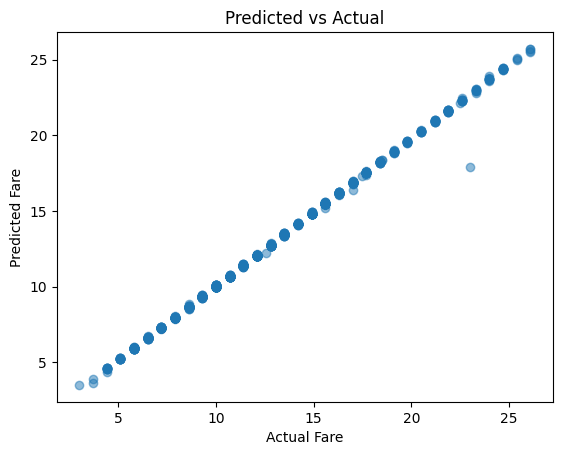

In [63]:
import matplotlib.pyplot as plt

plt.scatter(targets[:1000], preds[:1000], alpha=0.5)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs Actual")
plt.show()

In [64]:
print(preds[:10])
print(targets[:10])

[[10.003704]
 [12.126624]
 [12.824041]
 [13.453022]
 [ 8.65201 ]
 [16.163212]
 [ 5.874241]
 [10.677733]
 [10.733397]
 [12.698439]]
[[10. ]
 [12.1]
 [12.8]
 [13.5]
 [ 8.6]
 [16.3]
 [ 5.8]
 [10.7]
 [10.7]
 [12.8]]


In [65]:
print(X.columns)

Index(['passenger_count', 'trip_distance', 'payment_type', 'duration',
       'fare_per_km', 'speed', 'log_distance', 'log_duration'],
      dtype='object')
